In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as matplot
import seaborn as sb

import json
import requests
import time
import os
import logging

# Convert to .csv and load data

In [2]:
import csv
from xml.dom import minidom

def xml_to_csv(xml_file, csv_file, record_tag):
    # Parse the XML file
    dom_tree = minidom.parse(xml_file)
    collection = dom_tree.documentElement

    # Get all record elements (e.g., <employee>)
    records = collection.getElementsByTagName(record_tag)

    # Extract headers from the first record
    headers = [node.tagName for node in records[0].childNodes if node.nodeType == node.ELEMENT_NODE]

    # Open CSV file for writing
    with open(csv_file, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(headers)

        # Write each record’s data
        for record in records:
            row = []
            for header in headers:
                element = record.getElementsByTagName(header)[0]
                value = element.firstChild.nodeValue if element.firstChild else ''
                row.append(value)
            writer.writerow(row)

    print(f"XML data successfully written to '{csv_file}'")

# Example usage
if __name__ == "__main__":
    xml_to_csv("/Users/huynhphuongchi/Desktop/Unipi/DSS/Module 2/LDS Data 2025-2026/artists.xml", "artists.csv", "row")

XML data successfully written to 'artists.csv'


In [3]:
raw_data = pd.read_csv('artists.csv', skipinitialspace=True)

In [4]:
df_cleaned = raw_data.copy()

# General information

In [5]:
raw_data

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
0,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
2,ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,ART98118784,tormento,M,1975-09-06,Reggio Calabria,Italia,"rapper, cantautore e beatmaker italiano (1975-)",NaN,NaN,Reggio Calabria,Calabria,Italia,38.103539,15.639756
100,ART15560128,vacca,M,1979-10-21,Cagliari,Italia,rapper italiano,2001-01-01,NaN,Cagliari,Sardegna,Italia,39.217199,9.113311
101,ART57587384,willie peyote,M,1985-08-28,Torino,Italia,rapper e cantautore italiano (1985-),2004-01-01,NaN,Torino,Piemonte,Italia,45.067755,7.682489
102,ART71515715,yeиdry,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_author     104 non-null    object 
 1   name          104 non-null    object 
 2   gender        104 non-null    object 
 3   birth_date    73 non-null     object 
 4   birth_place   72 non-null     object 
 5   nationality   71 non-null     object 
 6   description   86 non-null     object 
 7   active_start  50 non-null     object 
 8   active_end    0 non-null      float64
 9   province      70 non-null     object 
 10  region        68 non-null     object 
 11  country       70 non-null     object 
 12  latitude      72 non-null     float64
 13  longitude     72 non-null     float64
dtypes: float64(3), object(11)
memory usage: 11.5+ KB


In [7]:
raw_data.birth_place.value_counts()

birth_place
Milano                      15
Roma                         7
Torino                       4
Vicenza                      3
Olbia                        3
Napoli                       3
Salerno                      2
Avellino                     2
Senigallia                   2
Verona                       1
San Siro                     1
San Benedetto del Tronto     1
Scafati                      1
Pieve Emanuele               1
Grugliasco                   1
Treviso                      1
Lodi                         1
Sesto San Giovanni           1
Buenos Aires                 1
Genova                       1
Fiumicino                    1
Padova                       1
Reggio Calabria              1
Desenzano del Garda          1
Scampia                      1
Gallarate                    1
Nicosia                      1
Grottaglie                   1
Rho                          1
Firenze                      1
Brescia                      1
Alpignano                  

- birth_place can be city or country

In [8]:
raw_data.country.value_counts()

country
Italia    70
Name: count, dtype: int64

In [9]:
raw_data.nationality.value_counts()

nationality
Italia       70
Argentina     1
Name: count, dtype: int64

In [10]:
df_cleaned["country"] = df_cleaned["country"].replace("Italia", "Italy")

In [11]:
df_cleaned.country.value_counts()

country
Italy    70
Name: count, dtype: int64

In [12]:
df_cleaned["nationality"] = df_cleaned["nationality"].replace("Italia", "Italy")

In [13]:
df_cleaned.nationality.value_counts()

nationality
Italy        70
Argentina     1
Name: count, dtype: int64

# Handling missing value

In [14]:
def missing_values(data : pd.DataFrame, threshold : float = 10):

    na_count = data.isna().sum()
    na_exist = na_count[na_count > 0]
    na_abs_frq = na_exist.values
    na_rel_frq = round(na_exist/len(data)*100)
    missings = pd.DataFrame({'Nº of missings': na_abs_frq, '% of missings': na_rel_frq})
    missings = missings.sort_values(by = 'Nº of missings', ascending = False)

    if threshold:
        missings['Above threshold'] = [True if x > threshold else False for x in missings['% of missings']]
    
    return missings

missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
active_end,104,100.0,True
active_start,54,52.0,True
region,36,35.0,True
province,34,33.0,True
country,34,33.0,True
nationality,33,32.0,True
birth_place,32,31.0,True
latitude,32,31.0,True
longitude,32,31.0,True
birth_date,31,30.0,True


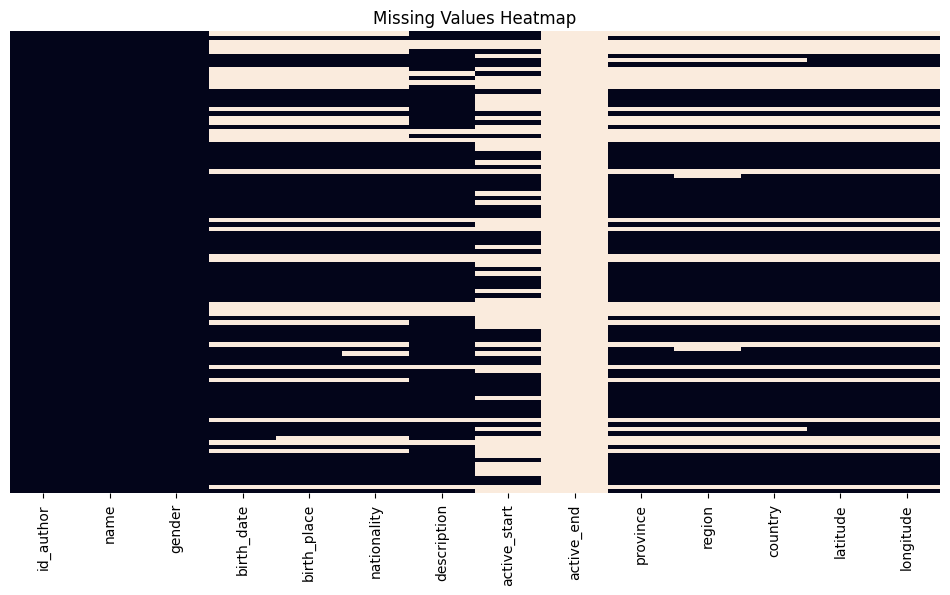

In [15]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

## Discussion

- Drop column "active-end" (100% mjssing) or fill from external data
- Use text in "description" to fill "nationality", then use API
- latitude/longtitude to fill province/region/country (Using Uber H3)
- Finally, drop row which has more than 50% missing columns

## metadata (birth_dat,birth_place,active_start,active_end,latitude,longtitude)

In [16]:
import csv
import json
import os
import time
import logging
import requests

# CONFIGURATION
INPUT_CSV = "artists.csv"
OUTPUT_CSV = "artists_enriched.csv"

CACHE_DIR = "./cache"
MB_CACHE_FILE = os.path.join(CACHE_DIR, "musicbrainz_cache.json")
WIKI_CACHE_FILE = os.path.join(CACHE_DIR, "wikipedia_summary_cache.json")

os.makedirs(CACHE_DIR, exist_ok=True)

MB_TARGET_MAP = {
    "birth_date": "birth_date",
    "area_name": "birth_place",
    "country": "country",
    "active_start": "active_start"
}

WIKI_TARGET_MAP = {
    "country": "nationality",
    "description": "description"
}

# Rate limiting
WAIT_BETWEEN = 1.2
MB_RETRIES = 4
MB_BACKOFF = 1.5

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger("artist_enrich")

# Cache helpers
def load_json_cache(path):
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        except:
            return {}
    return {}

def save_json_cache(path, obj):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)

MB_CACHE = load_json_cache(MB_CACHE_FILE)
WIKI_CACHE = load_json_cache(WIKI_CACHE_FILE)

# HTTP session
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Artist-Enrich/1.0",
    "Accept": "application/json",
})

def safe_get(url, params=None, timeout=12):
    try:
        r = SESSION.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        return r
    except:
        return None

# MUSICBRAINZ
def mb_search_artist_http(name, limit=1):
    url = "https://musicbrainz.org/ws/2/artist/"
    params = {"query": f'artist:"{name}"', "fmt": "json", "limit": str(limit)}
    r = safe_get(url, params=params, timeout=15)
    if not r:
        return None
    try:
        data = r.json()
        artists = data.get("artists") or []
        return artists[0] if artists else None
    except:
        return None

def mb_search_with_retry(name):
    if name in MB_CACHE:
        return MB_CACHE[name]
    for attempt in range(1, MB_RETRIES + 1):
        time.sleep(WAIT_BETWEEN)
        artist = mb_search_artist_http(name)
        if artist:
            out = {
                "country": artist.get("country"),
                "gender": artist.get("gender"),
                "birth_date": (artist.get("life-span") or {}).get("begin"),
                "active_start": (artist.get("life-span") or {}).get("begin"),
                "active_end": (artist.get("life-span") or {}).get("end"),
                "area_name": (artist.get("area") or {}).get("name")
            }
            MB_CACHE[name] = out
            save_json_cache(MB_CACHE_FILE, MB_CACHE)
            return out
       
        # retry with backoff
        time.sleep(WAIT_BETWEEN * MB_BACKOFF * attempt)
    return None

# WIKIPEDIA SUMMARY
COUNTRY_MAP = {
    "italian": "Italy",
    "italiana": "Italy",
    "italiani": "Italy",
    "american": "USA",
    "french": "France",
    "british": "United Kingdom",
    "japanese": "Japan",
    "german": "Germany",
    "spanish": "Spain",
}

def wiki_summary(name):
    if name in WIKI_CACHE:
        return WIKI_CACHE[name]

    slug = name.replace(" ", "_")
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{slug}"
    r = safe_get(url, timeout=10)

    if not r:
        slug2 = name.title().replace(" ", "_")
        url2 = f"https://en.wikipedia.org/api/rest_v1/page/summary/{slug2}"
        r = safe_get(url2, timeout=10)
        if not r:
            return None

    try:
        data = r.json()
    except:
        return None

    desc = data.get("extract") or data.get("description") or ""
    desc_norm = desc.lower()
    country = None
    for k, v in COUNTRY_MAP.items():
        if k in desc_norm:
            country = v
            break

    out = {"description": desc, "country": country}
    WIKI_CACHE[name] = out
    save_json_cache(WIKI_CACHE_FILE, WIKI_CACHE)
    return out

def is_missing(v):
    if v is None:
        return True
    if isinstance(v, str) and v.strip() == "":
        return True
    return False

def read_csv(filename):
    """Read CSV and return (fieldnames, list of dicts)"""
    with open(filename, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames
        rows = [dict(row) for row in reader]
    return fieldnames, rows

def write_csv(filename, fieldnames, rows):
    """Write CSV from fieldnames and list of dicts"""
    with open(filename, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

# FILL MB
def fill_from_musicbrainz(rows):
    filled = []
    for idx, row in enumerate(rows):
        name = str(row.get("name", "")).strip()

        # check if any MB field missing
        need = any(is_missing(row.get(col)) for col in MB_TARGET_MAP.values())
        if not need:
            continue

        logger.info("MusicBrainz: %s (row %s)", name, idx)
        mb = mb_search_with_retry(name)
        if not mb:
            continue

        updates = {}
        for src, tgt in MB_TARGET_MAP.items():
            val = mb.get(src)
            if val and is_missing(row.get(tgt)):
                row[tgt] = val
                updates[tgt] = val

        if updates:
            filled.append((idx, name, updates))

    print("\nFilled from MusicBrainz: {} rows".format(len(filled)))
    for i, name, u in filled:
        print(f"  Row {i} | {name} | Filled: {u}")
    return rows

# FILL WIKIPEDIA
def fill_from_wikipedia(rows):
    filled = []
    for idx, row in enumerate(rows):
        name = str(row.get("name", "")).strip()

        need = any(is_missing(row.get(col)) for col in WIKI_TARGET_MAP.values())
        if not need:
            continue

        logger.info("Wikipedia: %s (row %s)", name, idx)
        w = wiki_summary(name)
        if not w:
            continue

        updates = {}
        nationality = w.get("country")
        desc = w.get("description")

        if nationality and is_missing(row.get("nationality")):
            row["nationality"] = nationality
            updates["nationality"] = nationality

        if desc and is_missing(row.get("description")):
            row["description"] = desc
            updates["description"] = desc

        if updates:
            filled.append((idx, name, updates))

    print("\nFilled from Wikipedia Summary: {} rows".format(len(filled)))
    for i, name, u in filled:
        print(f"  Row {i} | {name} | Filled: {u}")
    return rows

# MAIN PIPELINE (NO OVERWRITE)
def run_pipeline():
    logger.info("Loading input CSV (read-only): %s", INPUT_CSV)
    fieldnames, rows = read_csv(INPUT_CSV)

    rows = fill_from_musicbrainz(rows)
    rows = fill_from_wikipedia(rows)

    logger.info("Saving enriched file to: %s", OUTPUT_CSV)
    write_csv(OUTPUT_CSV, fieldnames, rows)

    save_json_cache(MB_CACHE_FILE, MB_CACHE)
    save_json_cache(WIKI_CACHE_FILE, WIKI_CACHE)
    logger.info("Done.")

if __name__ == "__main__":
    run_pipeline()

2025-12-24 03:57:33,898 INFO Loading input CSV (read-only): artists.csv
2025-12-24 03:57:33,898 INFO MusicBrainz: 99 posse (row 0)
2025-12-24 03:57:33,899 INFO MusicBrainz: alfa (row 2)
2025-12-24 03:57:33,899 INFO MusicBrainz: anna pepe (row 3)
2025-12-24 03:57:58,218 INFO MusicBrainz: articolo 31 (row 4)
2025-12-24 03:57:58,219 INFO MusicBrainz: babaman (row 5)
2025-12-24 03:57:58,220 INFO MusicBrainz: baby k (row 6)
2025-12-24 03:57:58,221 INFO MusicBrainz: beba (row 8)
2025-12-24 03:57:58,222 INFO MusicBrainz: bigmama (row 9)
2025-12-24 03:57:58,224 INFO MusicBrainz: brusco (row 10)
2025-12-24 03:57:58,224 INFO MusicBrainz: bushwaka (row 11)
2025-12-24 03:57:58,225 INFO MusicBrainz: caneda (row 12)
2025-12-24 03:57:58,225 INFO MusicBrainz: capo plaza (row 14)
2025-12-24 03:57:58,226 INFO MusicBrainz: chadia rodriguez (row 15)
2025-12-24 03:57:58,227 INFO MusicBrainz: clementino (row 16)
2025-12-24 03:57:58,227 INFO MusicBrainz: club dogo (row 17)
2025-12-24 03:57:58,228 INFO MusicB


Filled from MusicBrainz: 47 rows
  Row 0 | 99 posse | Filled: {'birth_place': 'Italy', 'country': 'IT'}
  Row 2 | alfa | Filled: {'birth_place': 'Genova', 'active_start': '2000-08-22'}
  Row 4 | articolo 31 | Filled: {'birth_date': '1990', 'birth_place': 'Italy', 'country': 'IT'}
  Row 5 | babaman | Filled: {'active_start': '1975-08-08'}
  Row 6 | baby k | Filled: {'country': 'IT'}
  Row 8 | beba | Filled: {'birth_date': '1939-03-27', 'birth_place': 'Bosnia and Herzegovina', 'country': 'BA', 'active_start': '1939-03-27'}
  Row 9 | bigmama | Filled: {'birth_date': '2001', 'birth_place': 'Japan', 'country': 'JP'}
  Row 10 | brusco | Filled: {'birth_date': '1974-01-04', 'birth_place': 'Italy', 'country': 'IT', 'active_start': '1974-01-04'}
  Row 12 | caneda | Filled: {'birth_date': '1976-09-30', 'birth_place': 'Italy', 'country': 'IT', 'active_start': '1976-09-30'}
  Row 14 | capo plaza | Filled: {'active_start': '1998'}
  Row 15 | chadia rodriguez | Filled: {'active_start': '1998-11-06'

2025-12-24 04:01:09,598 INFO Wikipedia: brusco (row 10)
2025-12-24 04:01:09,599 INFO Wikipedia: bushwaka (row 11)
2025-12-24 04:01:09,702 INFO Wikipedia: caneda (row 12)
2025-12-24 04:01:09,804 INFO Wikipedia: club dogo (row 17)
2025-12-24 04:01:09,805 INFO Wikipedia: colle der fomento (row 19)
2025-12-24 04:01:09,906 INFO Wikipedia: cor veleno (row 20)
2025-12-24 04:01:09,908 INFO Wikipedia: dargen d_amico (row 22)
2025-12-24 04:01:10,009 INFO Wikipedia: dark polo gang (row 23)
2025-12-24 04:01:10,010 INFO Wikipedia: doll kill (row 24)
2025-12-24 04:01:10,112 INFO Wikipedia: eva rea (row 31)
2025-12-24 04:01:10,216 INFO Wikipedia: guè pequeno (row 42)
2025-12-24 04:01:10,217 INFO Wikipedia: hindaco (row 44)
2025-12-24 04:01:10,317 INFO Wikipedia: joey funboy (row 50)
2025-12-24 04:01:10,421 INFO Wikipedia: johnny marsiglia (row 51)
2025-12-24 04:01:10,524 INFO Wikipedia: mike24 (row 61)
2025-12-24 04:01:10,629 INFO Wikipedia: miss keta (row 62)
2025-12-24 04:01:10,732 INFO Wikipedia: 


Filled from Wikipedia Summary: 9 rows
  Row 0 | 99 posse | Filled: {'nationality': 'Italy'}
  Row 2 | alfa | Filled: {'description': 'Alfa may refer to:'}
  Row 3 | anna pepe | Filled: {'nationality': 'Italy', 'description': 'Anna Pepe, known professionally as Anna, is an Italian rapper. She was born in La Spezia, in Liguria, Italy. Her father is a DJ and her mother a sculptor. In 2020, she became the youngest artist to top the Italian singles chart with "Bando", her debut single.'}
  Row 4 | articolo 31 | Filled: {'nationality': 'Italy'}
  Row 10 | brusco | Filled: {'nationality': 'Italy'}
  Row 17 | club dogo | Filled: {'nationality': 'Italy'}
  Row 20 | cor veleno | Filled: {'nationality': 'Italy'}
  Row 23 | dark polo gang | Filled: {'nationality': 'Italy'}
  Row 42 | guè pequeno | Filled: {'nationality': 'Italy', 'description': 'Cosimo Fini, known professionally as Guè, previously as Gué Pequeno, is an Italian rapper. He is also a member of the famous hip hop group Club Dogo with

In [17]:
df_cleaned = pd.read_csv('artists_enriched.csv')

In [18]:
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
active_end,104,100.0,True
region,36,35.0,True
province,34,33.0,True
latitude,32,31.0,True
longitude,32,31.0,True
nationality,25,24.0,True
active_start,18,17.0,True
birth_date,16,15.0,True
description,15,14.0,True
country,12,12.0,True


In [19]:
df_cleaned.birth_place.value_counts()

birth_place
Italy                       17
Milano                      15
Roma                         7
Torino                       4
Vicenza                      3
Napoli                       3
Olbia                        3
Senigallia                   2
Salerno                      2
Avellino                     2
Genova                       2
Grugliasco                   1
Desenzano del Garda          1
San Benedetto del Tronto     1
Scafati                      1
Pieve Emanuele               1
Montréal                     1
San Siro                     1
Japan                        1
Lodi                         1
Gallarate                    1
Sesto San Giovanni           1
Buenos Aires                 1
India                        1
Fiumicino                    1
Padova                       1
Reggio Calabria              1
Treviso                      1
Grottaglie                   1
Nicosia                      1
Sternatia                    1
Scampia                    

In [20]:
df_cleaned.nationality.value_counts()

nationality
Italia       70
Italy         8
Argentina     1
Name: count, dtype: int64

In [21]:
rows = []
with open('artists_enriched.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

nationality_map = {
    "Italia": "Italy"
}

for row in rows:
    if row.get("nationality") in nationality_map:
        row["nationality"] = nationality_map[row["nationality"]]

fieldnames = rows[0].keys() if rows else []

with open('artists_enriched.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

In [22]:
df_cleaned = pd.read_csv('artists_enriched.csv')
df_cleaned.nationality.value_counts()

nationality
Italy        78
Argentina     1
Name: count, dtype: int64

In [28]:
df_cleaned.country.value_counts()

country
Italy                     89
Bosnia and Herzegovina     1
Japan                      1
India                      1
Name: count, dtype: int64

In [24]:
rows = []
with open('artists_enriched.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

country_map = {
    "Italia": "Italy",
    "IT": "Italy",
    "BA": "Bosnia and Herzegovina",
    "JP": "Japan",
    "IN": "India"
}

for row in rows:
        if row.get("country") in country_map:
            row["country"] = country_map[row["country"]]

fieldnames = rows[0].keys() if rows else []

with open('artists_enriched.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

## active_end

In [25]:
rows = []
with open('artists_enriched.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

def drop_columns(rows, columns_to_drop):
    if not rows:
        return [], rows

    fieldnames = [k for k in rows[0].keys() if k not in columns_to_drop]

    for row in rows:
        for col in columns_to_drop:
            row.pop(col, None)

    return fieldnames, rows

fieldnames, rows = drop_columns(rows, ['active_end'])

with open('artists_enriched.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

In [26]:
df_cleaned = pd.read_csv('artists_enriched.csv')
df_cleaned_copy=df_cleaned.copy()

In [27]:
df_cleaned

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,province,region,country,latitude,longitude
0,ART82291002,99 posse,M,NaN,Italy,Italy,gruppo musicale italiano,1991-01-01,NaN,NaN,Italy,NaN,NaN
1,ART53496045,achille lauro,M,1990-07-11,Verona,Italy,cantautore e rapper italiano (1990-),2012-01-01,Verona,Veneto,Italy,45.442498,10.985738
2,ART18853907,alfa,M,NaN,Genova,NaN,Alfa may refer to:,2000-08-22,NaN,NaN,NaN,NaN,NaN
3,ART64265460,anna pepe,F,NaN,NaN,Italy,"Anna Pepe, known professionally as Anna, is an...",NaN,NaN,NaN,NaN,NaN,NaN
4,ART75741740,articolo 31,M,1990,Italy,Italy,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,Italy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,ART98118784,tormento,M,1975-09-06,Reggio Calabria,Italy,"rapper, cantautore e beatmaker italiano (1975-)",1975-09-06,Reggio Calabria,Calabria,Italy,38.103539,15.639756
100,ART15560128,vacca,M,1979-10-21,Cagliari,Italy,rapper italiano,2001-01-01,Cagliari,Sardegna,Italy,39.217199,9.113311
101,ART57587384,willie peyote,M,1985-08-28,Torino,Italy,rapper e cantautore italiano (1985-),2004-01-01,Torino,Piemonte,Italy,45.067755,7.682489
102,ART71515715,yeиdry,F,1993-07-27,Italy,NaN,NaN,1993-07-27,NaN,NaN,Italy,NaN,NaN


## province/region/country

- Infer from 'birth_place': 'province' and 'country'

In [29]:
def classify_birthplace(rows):
    """Classify birth_place into country or province"""
    countries = {"italy", "japan", "india", "singapore", "bosnia and herzegovina"}
    
    for row in rows:
        row["for_country"] = None
        row["for_province"] = None
        
        bp = row.get("birth_place")
        
        if not bp or not isinstance(bp, str) or bp.strip() == "":
            continue
        
        bp_clean = bp.strip()
        bp_lower = bp_clean.lower()
        
        # Check if it's a country
        if bp_lower in countries:
            row["for_country"] = bp_clean
        else:
            row["for_province"] = bp_clean
    
    return rows

def fill_province_country(rows):
    """Fill missing province and country from classified fields"""
    for row in rows:
        # Fill province
        if not row.get("province") or str(row.get("province")).strip() == "":
            prov = row.get("for_province")
            if isinstance(prov, str) and prov.strip() != "":
                row["province"] = prov
        
        # Fill country
        if not row.get("country") or str(row.get("country")).strip() == "":
            cn = row.get("for_country")
            if isinstance(cn, str) and cn.strip() != "":
                row["country"] = cn
    
    return rows

def drop_columns(rows, fieldnames, columns_to_drop):
    """Remove specified columns"""
    # Remove from fieldnames
    fieldnames = [col for col in fieldnames if col not in columns_to_drop]
    
    # Remove from rows
    for row in rows:
        for col in columns_to_drop:
            if col in row:
                del row[col]
    
    return fieldnames, rows

def process_artists(input_file, output_file):
    """Read, process, and save artists data"""
    
    # Read CSV
    with open(input_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames
        rows = [dict(row) for row in reader]
    
    # Process
    rows = classify_birthplace(rows)
    rows = fill_province_country(rows)
    fieldnames, rows = drop_columns(rows, fieldnames, ["for_province", "for_country"])
    
    # Write CSV
    with open(output_file, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    
    print(f"Processed {len(rows)} rows and saved to {output_file}")

if __name__ == "__main__":
    process_artists('artists_enriched.csv', 'artists_enriched_clean.csv')

Processed 104 rows and saved to artists_enriched_clean.csv


In [30]:
df_cleaned = pd.read_csv('artists_enriched_clean.csv')
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
region,36,35.0,True
latitude,32,31.0,True
longitude,32,31.0,True
province,31,30.0,True
nationality,25,24.0,True
active_start,18,17.0,True
birth_date,16,15.0,True
description,15,14.0,True
country,12,12.0,True
birth_place,10,10.0,False


- Use province to infer region/country:

In [31]:
df_cleaned[df_cleaned.province.notna() & df_cleaned.region.isna()]

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,province,region,country,latitude,longitude
2,ART18853907,alfa,M,NaN,Genova,NaN,Alfa may refer to:,2000-08-22,Genova,NaN,NaN,NaN,NaN
32,ART25707984,fabri fibra,M,1976-10-17,Senigallia,Italy,rapper italiano (1976-),1996-01-01,Ancona,NaN,Italy,43.714952,13.217949
71,ART07629990,nesli,M,1980-12-29,Senigallia,Italy,"cantautore, rapper e produttore discografico i...",1990-01-01,Ancona,NaN,Italy,43.714952,13.217949
78,ART87389753,priestess,F,2004-10,Montréal,NaN,gruppo musicale canadese,2003-01-01,Montréal,NaN,NaN,NaN,NaN
89,ART98307962,shablo,M,1980-11-17,Buenos Aires,Argentina,disc jockey e produttore discografico italo-ar...,1980-11-17,Buenos Aires,NaN,Italy,44.803741,10.143004


In [32]:
rows = []
fieldnames = None

with open('artists_enriched_clean.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    fieldnames = reader.fieldnames  # Lấy fieldnames từ đây
    for row in reader:
        rows.append(row)

def update_region_country(rows, province_mapping):
    for row in rows:
        province = row.get("province")
        if province in province_mapping:
            row.update(province_mapping[province])
    return rows

province_mapping = {
    "Ancona": {"region": "Marche", "country": "Italy"},
    "Genova": {"region": "Liguria", "country": "Italy"},
    "Montréal": {"region": "Québec", "country": "Canada"},
    "Buenos Aires": {"region": "Greater Buenos Aires", "country": "Argentina"},
}

rows = update_region_country(rows, province_mapping)
with open('artists_enriched_clean.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

- Infer from provided lat/lon:

In [33]:
df_cleaned = pd.read_csv('artists_enriched_clean.csv')
has_coords = df_cleaned["latitude"].notna() & df_cleaned["longitude"].notna()

missing_location = (
    df_cleaned["province"].isna() | (df_cleaned["province"] == "") |
    df_cleaned["region"].isna()   | (df_cleaned["region"] == "") |
    df_cleaned["country"].isna()  | (df_cleaned["country"] == "")
)

result = df_cleaned[has_coords & missing_location]

print("Mising location but have lat/long:", len(result))

Mising location but have lat/long: 1


In [34]:
import requests
import time

rows = []
fieldnames = None

with open('artists_enriched_clean.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    fieldnames = reader.fieldnames 
    for row in reader:
        rows.append(row)
        
def infer_location(lat, lon):
    """Infer location from latitude and longitude"""
    url = "https://api.bigdatacloud.net/data/reverse-geocode-client"
    params = {
        "latitude": lat,
        "longitude": lon,
        "localityLanguage": "en"
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        province = data.get("principalSubdivision")    
        country  = data.get("countryName")            
        region_info = data.get("localityInfo", {}).get("administrative", [])
        region = None
        if len(region_info) > 1:
            region = region_info[1].get("name")
        return province, region, country
    except Exception as e:
        print(f"Error for {lat},{lon}: {e}")
        return None, None, None

def fill_location_from_coordinates(rows):
    """Fill missing province, region, country from latitude/longitude"""
    for idx, row in enumerate(rows):
        lat = row.get("latitude")
        lon = row.get("longitude")
        
        # Check if lat/lon are valid
        if not lat or not lon:
            try:
                lat = float(lat)
                lon = float(lon)
            except (ValueError, TypeError):
                continue
        
        # Check what's missing
        missing_province = not row.get("province") or str(row.get("province")).strip() == ""
        missing_region   = not row.get("region") or str(row.get("region")).strip() == ""
        missing_country  = not row.get("country") or str(row.get("country")).strip() == ""
        
        if missing_province or missing_region or missing_country:
            province, region, country = infer_location(lat, lon)
            
            if missing_province and province:
                row["province"] = province
            if missing_region and region:
                row["region"] = region
            if missing_country and country:
                row["country"] = country
            
            print(f"Row {idx} → {province}, {region}, {country}")
            time.sleep(0.2)
    
    return rows

rows = fill_location_from_coordinates(rows)
with open('artists_enriched_clean.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

Row 6 → Piemonte, Northwest Italy, Italy


## lattitude/longtitude

- Only use exactly location (city/province) to infer lat/lon. Use country is wrong, because geocode will return lat/lon of the capital of that country, ex: geocode("Italy") = 41.8719, 12.5674 (ROME)

In [35]:
def geocode_place(place_name):
    """
    Geocode ONLY the province.
    Returns (latitude, longitude) or (None, None)
    """
    if place_name is None or str(place_name).strip() == "" or place_name != place_name:
        return None, None
    
    place_name = str(place_name).strip()
    query = place_name
    url = "https://nominatim.openstreetmap.org/search"
    params = {"q": query, "format": "json", "limit": 1}
    headers = {"User-Agent": "Mozilla/5.0 (Academic Research)"}
    
    try:
        r = requests.get(url, params=params, headers=headers)
        r.raise_for_status()
    except:
        return None, None
    
    data = r.json()
    if len(data) == 0:
        return None, None
    
    try:
        return float(data[0]["lat"]), float(data[0]["lon"])
    except:
        return None, None

def is_missing_coordinate(value):
    """Check if coordinate value is missing"""
    if value is None:
        return True
    if str(value).strip() in ["", "0"]:
        return True
    return False

def fill_from_geocode(rows):
    """Fill missing latitude and longitude from province geocoding"""
    print("\nGeocoding enrichment:\n")
    filled = []
    
    for idx, row in enumerate(rows):
        need_lat = is_missing_coordinate(row.get("latitude"))
        need_lon = is_missing_coordinate(row.get("longitude"))
        
        if not (need_lat or need_lon):
            continue
        
        # Use ONLY province
        province = row.get("province")
        if not isinstance(province, str) or province.strip() == "":
            continue
        
        place = province.strip()
        
        # Geocode
        lat, lon = geocode_place(place)
        time.sleep(1)  # respect Nominatim rate limit
        
        if lat is None or lon is None:
            continue
        
        updates = {}
        if need_lat:
            row["latitude"] = lat
            updates["latitude"] = lat
        if need_lon:
            row["longitude"] = lon
            updates["longitude"] = lon
        
        filled.append((idx, row.get("name"), updates))
    
    # Print results
    print(f"\nFilled from Geocoding: {len(filled)} rows\n")
    for idx, name, updates in filled:
        print(f"Row {idx} | {name}")
        for col, value in updates.items():
            print(f"  → Filled {col}: {value}")
        print()
    
    return rows

def process_geocoding(input_file, output_file):
    """Read CSV, geocode, and write back"""
    
    # Read CSV
    rows = []
    fieldnames = None
    with open(input_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames
        rows = [dict(row) for row in reader]
    
    # Process
    rows = fill_from_geocode(rows)
    
    # Write CSV
    with open(output_file, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    
    print(f"Saved to {output_file}")

# Usage
if __name__ == "__main__":
    process_geocoding('artists_enriched_clean.csv', 'artists_geocoded.csv')


Geocoding enrichment:


Filled from Geocoding: 2 rows

Row 2 | alfa
  → Filled latitude: 44.40726
  → Filled longitude: 8.9338624

Row 78 | priestess
  → Filled latitude: 45.5031824
  → Filled longitude: -73.5698065

Saved to artists_geocoded.csv


## nationality

Infer from 'description'

In [36]:
rows = []
fieldnames = None
with open('artists_enriched_clean.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    fieldnames = reader.fieldnames
    rows = [dict(row) for row in reader]

keyword_map = {
    "italiano": "Italia",
    "italiana": "Italia",
    "italiani": "Italia",
    "canadese": "Canadian",
    "francese": "French",
    "inglese": "British",
    "americano": "American",
    "americana": "American",
    "indiano": "Indian"
}

def infer_nationality(description):
    """Infer nationality from description"""
    if not description or not isinstance(description, str):
        return None
    desc = description.lower()
    for kw, nat in keyword_map.items():
        if kw in desc:
            return nat
    return None

def is_nationality_empty(nat):
    """Check if nationality field is empty"""
    if nat is None:
        return True
    if isinstance(nat, float):
        return True
    if isinstance(nat, str) and nat.strip() == "":
        return True
    return False

# Process
for row in rows:
    nat = row.get("nationality")
    desc = row.get("description")
    
    if not is_nationality_empty(nat):
        continue
    
    if not desc or not isinstance(desc, str) or desc.strip() == "":
        continue
    
    inferred = infer_nationality(desc)
    if inferred:
        row["nationality"] = inferred

# Count missing nationality
missing_count = sum(1 for row in rows if is_nationality_empty(row.get("nationality")))
print(f"Missing nationality now: {missing_count}")

# Write CSV
with open('artists_enriched_clean.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

Missing nationality now: 20


## non-valid artist

description but no matching kw:

In [37]:
df_cleaned=pd.read_csv('artists_enriched_clean.csv')
df_cleaned[(df_cleaned['nationality'].isna()) & (df_cleaned['description'].notna())]

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,province,region,country,latitude,longitude
2,ART18853907,alfa,M,NaN,Genova,NaN,Alfa may refer to:,2000-08-22,Genova,Liguria,Italy,NaN,NaN
8,ART19605256,beba,F,1939-03-27,Bosnia and Herzegovina,NaN,cognome,1939-03-27,NaN,NaN,Bosnia and Herzegovina,NaN,NaN
12,ART28846313,caneda,M,1976-09-30,Italy,NaN,cognome,1976-09-30,NaN,NaN,Italy,NaN,NaN
65,ART66452136,mistico,M,NaN,Italy,NaN,tipo di barca a vela usata nel XVIII e XIX secolo,NaN,NaN,NaN,Italy,NaN,NaN
70,ART62385172,nerone,M,1991-05-23,Italy,NaN,opera lirica di Pietro Mascagni,1991-05-23,NaN,NaN,Italy,NaN,NaN


=> Not valid artists.
They represent surnames, objects, or works. These will be removed as outliers

In [38]:
non_artist_keywords = [
    "cognome",                         # surname
    "tipo di barca",                   # boat type
    "tipo di barca a vela",            # sailing boat
    "opera lirica",                    # opera (not an artist)
]

def is_non_artist(desc):
    """Check if description indicates non-artist entry"""
    if not isinstance(desc, str):
        return False
    desc_lower = desc.lower()
    return any(keyword in desc_lower for keyword in non_artist_keywords)

def filter_non_artists(rows):
    """Remove rows that are not artists based on description"""
    filtered_rows = []
    removed_count = 0
    
    for idx, row in enumerate(rows):
        desc = row.get("description")
        
        if is_non_artist(desc):
            removed_count += 1
            continue
        
        filtered_rows.append(row)
    
    print(f"Removed {removed_count} non-artist rows")
    return filtered_rows

# Process
rows = filter_non_artists(rows)

# Write CSV
with open('artists_enriched_clean.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Total rows after filtering: {len(rows)}")

Removed 5 non-artist rows
Total rows after filtering: 99


In [39]:
raw_data.duplicated().any()

np.False_

In [40]:
def extract_year(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    if len(value) >= 4 and value[:4].isdigit():
        return value[:4]
    
    return np.nan

df_cleaned["birth_year"] = df_cleaned["birth_date"].apply(extract_year)
df_cleaned["active_year"] = df_cleaned["active_start"].apply(extract_year)
mask = df_cleaned["birth_year"].notna() & \
       df_cleaned["active_year"].notna() & \
       (df_cleaned["birth_year"] == df_cleaned["active_year"])

df_match = df_cleaned[mask]
df_cleaned = df_cleaned.drop(columns=["birth_year", "active_year"])
df_match[["name", "birth_date", "birth_year", "active_start", "active_year"]]

,name,birth_date,birth_year,active_start,active_year
4,articolo 31,1990,1990,1990-01-01,1990
5,babaman,1975-08-08,1975,1975-08-08,1975
8,beba,1939-03-27,1939,1939-03-27,1939
9,bigmama,2001,2001,2001-01-01,2001
10,brusco,1974-01-04,1974,1974-01-04,1974
12,caneda,1976-09-30,1976,1976-09-30,1976
14,capo plaza,1998-04-20,1998,1998,1998
15,chadia rodriguez,1998-11-07,1998,1998-11-06,1998
16,clementino,1982-12-21,1982,1982-12-21,1982
19,colle der fomento,1994,1994,1994,1994


Maybe these are not solo, they might be music group => birth_date = active_start (valid data)

## rows with 10 missing columns

In [41]:
df_cleaned=pd.read_csv('artists_enriched_clean.csv')
cols = set(df_cleaned.columns)

missing_cols = list(cols - {"id_author", "name", "gender"})

In [42]:
rows_all_missing = df_cleaned[df_cleaned[missing_cols].isna().all(axis=1)]
rows_all_missing

,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,province,region,country,latitude,longitude
9,ART95365016,bushwaka,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,ART63985757,dargen d_amico,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,ART14073567,eva rea,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,ART59593021,hindaco,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,ART88199433,joey funboy,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,ART37807199,mike24,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,ART43601431,miss keta,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,ART51628788,miss simpatia,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


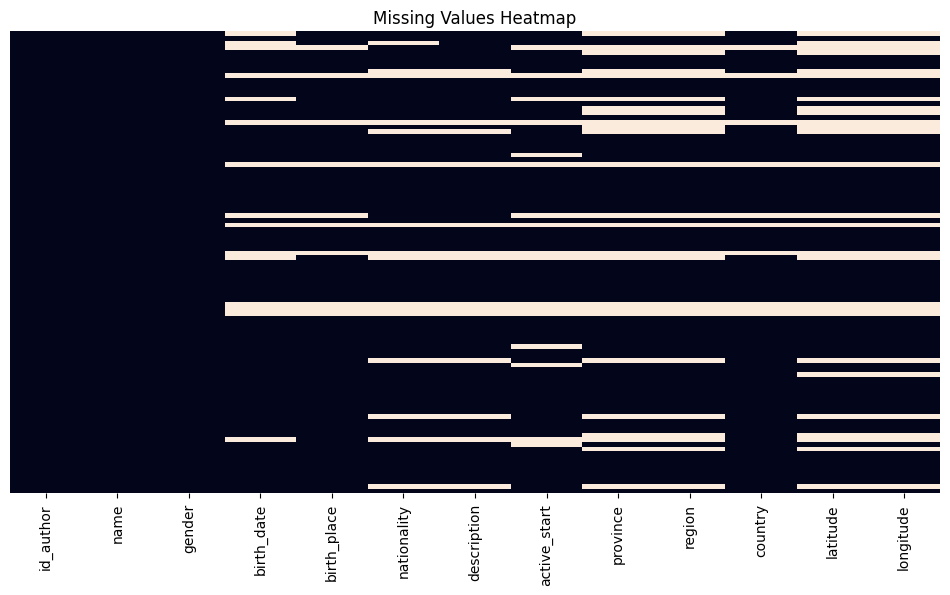

In [43]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [44]:
def fill_missing_values(rows, fill_value="unknown"):
    """Fill missing/None values with a default value"""
    for row in rows:
        for key in row.keys():
            if row[key] is None or str(row[key]).strip() == "":
                row[key] = fill_value
    return rows

rows = fill_missing_values(rows, fill_value="unknown")

with open('artists_enriched_clean.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Filled missing values with 'unknown'")
print(f"Saved to artists_cleaned.csv")

Filled missing values with 'unknown'
Saved to artists_cleaned.csv


In [45]:
df_cleaned=pd.read_csv('artists_enriched_clean.csv')
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold


In [46]:
df_cleaned.to_csv('/Users/huynhphuongchi/Desktop/Unipi/DSS/Module 2/LDS Data 2025-2026/artists_cleaned.csv', index=False)